In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# **Explotary Data analysis (EDA)**

The original raw file covers all of Nepal (~760K rows, 117MB) -- too big to
comfortably commit to a GitHub repo. Since this analysis only ever uses one district
anyway, I filtered it down and saved `nepal-earthquake-district24.csv` (the largest
district by row count) as the version that actually ships with this repo.

In [2]:
df = pd.read_csv("../data/nepal-earthquake-district24.csv")
df.head()

,building_id,district_id,count_floors_pre_eq,count_floors_post_eq,age_building,plinth_area_sq_ft,height_ft_pre_eq,height_ft_post_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,condition_post_eq,damage_grade
0,240101000011,24,1,1,40,324,12,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Not used,Grade 3
1,240101000021,24,2,0,30,382,20,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Attached-1 side,Rectangular,Damaged-Rubble unclear,Grade 5
2,240101000031,24,1,0,13,405,10,0,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,Damaged-Rubble unclear,Grade 5
3,240101000041,24,2,2,25,328,18,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular,Damaged-Not used,Grade 4
4,240101000051,24,2,1,15,405,20,7,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,Damaged-Not used,Grade 4


In [3]:
df.shape

(98019, 17)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98019 entries, 0 to 98018
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   building_id             98019 non-null  int64
 1   district_id             98019 non-null  int64
 2   count_floors_pre_eq     98019 non-null  int64
 3   count_floors_post_eq    98019 non-null  int64
 4   age_building            98019 non-null  int64
 5   plinth_area_sq_ft       98019 non-null  int64
 6   height_ft_pre_eq        98019 non-null  int64
 7   height_ft_post_eq       98019 non-null  int64
 8   land_surface_condition  98019 non-null  str  
 9   foundation_type         98019 non-null  str  
 10  roof_type               98019 non-null  str  
 11  ground_floor_type       98019 non-null  str  
 12  other_floor_type        98019 non-null  str  
 13  position                98019 non-null  str  
 14  plan_configuration      98019 non-null  str  
 15  condition_post_eq       98019 

In [5]:
df["damage_grade"].value_counts()

damage_grade
Grade 4    28974
Grade 3    25130
Grade 5    23859
Grade 2    11726
Grade 1     8330
Name: count, dtype: int64

# **Cleaning columns / feature engineering**

In [6]:
# testing cleaning steps loose before wrapping into a function
df_test = df[df["district_id"] == 24].copy()

# damage_grade comes in as strings like "Grade 3" -- pull out the number
df_test["damage_grade"] = df_test["damage_grade"].str[-1].astype(float)
df_test = df_test.dropna(subset=["damage_grade"])
df_test["damage_grade"] = df_test["damage_grade"].astype(int)

# binary target: Grade 4 or 5 counts as severe
df_test["severe_damage"] = (df_test["damage_grade"] > 3).astype(int)
df_test["severe_damage"].value_counts(normalize=True)

severe_damage
1    0.539008
0    0.460992
Name: proportion, dtype: float64

In [7]:
# columns with "post_eq" in the name describe the building AFTER the earthquake --
# using those to predict damage would be leakage, since we wouldn't have them in advance
[c for c in df_test.columns if "post_eq" in c]

['count_floors_post_eq', 'height_ft_post_eq', 'condition_post_eq']

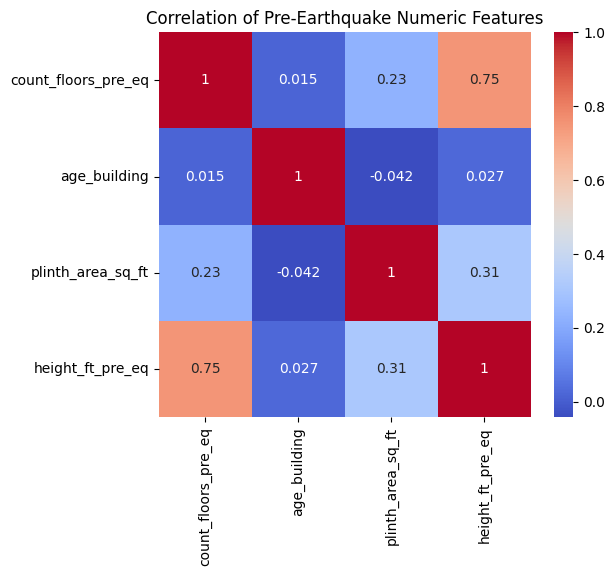

In [8]:
# checking for multicollinearity among the pre-earthquake numeric features
numeric_cols = ["count_floors_pre_eq", "age_building", "plinth_area_sq_ft", "height_ft_pre_eq"]
corr = df_test[numeric_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation of Pre-Earthquake Numeric Features")
plt.savefig("../images/correlation_heatmap.png", dpi=150)
plt.show()


`count_floors_pre_eq` and `height_ft_pre_eq` are correlated at 0.75 -- keeping both
would cause multicollinearity issues for the linear models later, so dropping
`count_floors_pre_eq` and keeping height instead (height is the more direct measurement).

In [9]:
# good, now wrap the cleaning steps into a function
def wrangle(filepath, district_id=24):
    df = pd.read_csv(filepath)
    df = df[df["district_id"] == district_id].copy()

    # parse the target grade out of strings like "Grade 3"
    df["damage_grade"] = df["damage_grade"].str[-1].astype(float)
    df = df.dropna(subset=["damage_grade"])
    df["damage_grade"] = df["damage_grade"].astype(int)

    # binary target: severe damage = Grade 4 or 5
    df["severe_damage"] = (df["damage_grade"] > 3).astype(int)

    # drop leaky post-earthquake columns, the old target, ids, and the
    # multicollinear column identified above
    drop_cols = [c for c in df.columns if "post_eq" in c]
    drop_cols += ["damage_grade", "building_id", "district_id", "count_floors_pre_eq"]
    df.drop(columns=drop_cols, inplace=True)

    # a couple of rows have nulls in position/plan_configuration -- just drop them
    df = df.dropna()
    return df


In [10]:
df = wrangle("../data/nepal-earthquake-district24.csv")
df.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration,severe_damage
0,40,324,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,0
1,30,382,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Attached-1 side,Rectangular,1
2,13,405,10,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular,1
3,25,328,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular,1
4,15,405,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular,1


In [11]:
df.shape

(98019, 11)

In [12]:
df.isnull().sum()

age_building              0
plinth_area_sq_ft         0
height_ft_pre_eq          0
land_surface_condition    0
foundation_type           0
roof_type                 0
ground_floor_type         0
other_floor_type          0
position                  0
plan_configuration        0
severe_damage             0
dtype: int64

In [13]:
df.select_dtypes("object").nunique()

/tmp/ipykernel_475/3517814742.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes("object").nunique()


land_surface_condition     3
foundation_type            5
roof_type                  3
ground_floor_type          5
other_floor_type           4
position                   4
plan_configuration        10
dtype: int64

# **Explore**

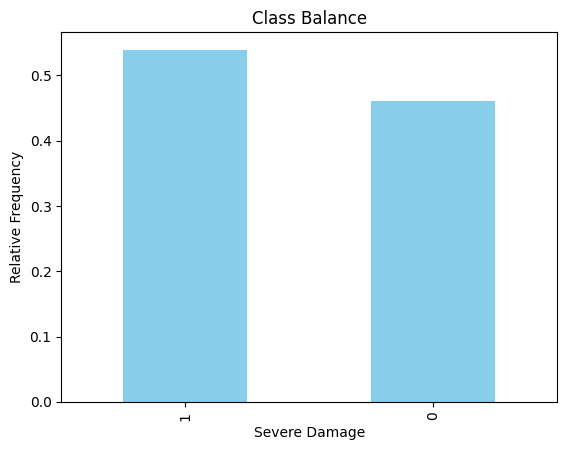

In [14]:
df["severe_damage"].value_counts(normalize=True).plot(
    kind="bar", color="skyblue",
    xlabel="Severe Damage", ylabel="Relative Frequency",
    title="Class Balance"
)
plt.savefig("../images/class_balance.png", dpi=150)
plt.show()


Classes aren't too imbalanced -- roughly 60/40 split. Good enough that accuracy is
still a reasonable metric to track, without needing to reach for something like F1 right away.

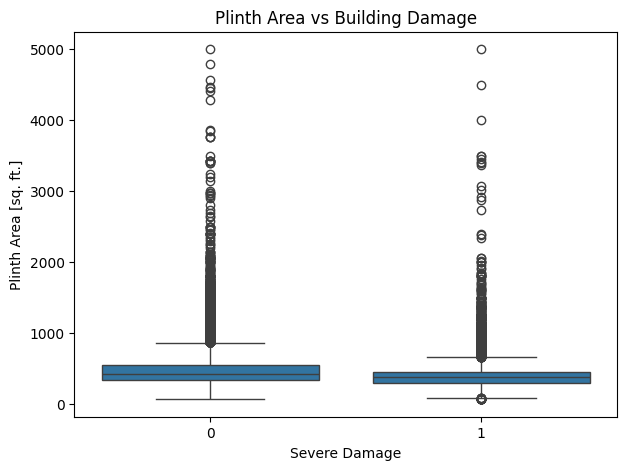

In [15]:
plt.figure(figsize=(7,5))
sns.boxplot(x="severe_damage", y="plinth_area_sq_ft", data=df)
plt.xlabel("Severe Damage")
plt.ylabel("Plinth Area [sq. ft.]")
plt.title("Plinth Area vs Building Damage")
plt.savefig("../images/plinth_area_vs_damage.png", dpi=150)
plt.show()


In [16]:
roof_pivot = pd.pivot_table(
    df, index="roof_type", values="severe_damage", aggfunc="mean"
).sort_values("severe_damage")
roof_pivot

,severe_damage
roof_type,
RCC/RB/RBC,0.037574
Bamboo/Timber-Heavy roof,0.570629
Bamboo/Timber-Light roof,0.601164


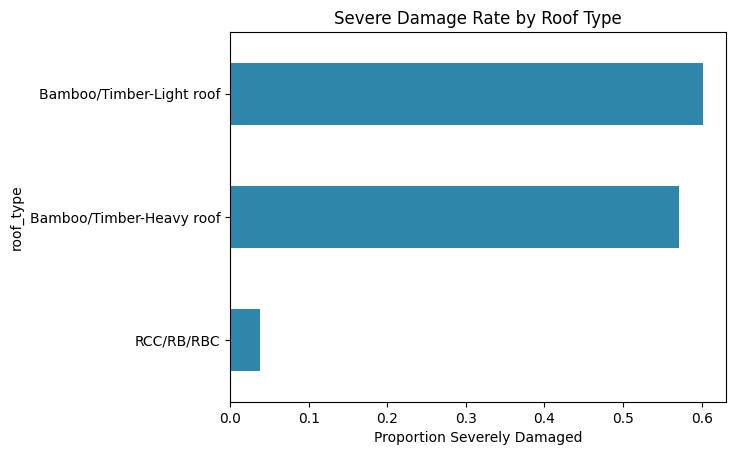

In [17]:
roof_pivot.plot(kind="barh", legend=False, color="#2E86AB")
plt.xlabel("Proportion Severely Damaged")
plt.title("Severe Damage Rate by Roof Type")
plt.savefig("../images/roof_type_damage.png", dpi=150)
plt.show()


Roof type looks like it matters a lot -- buildings with heavier bamboo/timber roofs
show up with very different damage rates than lighter or RCC roofs. Worth watching whether
this shows up again in feature importance once the models are built.

# **Splitting Data into Feature Matrix and target vector**

In [18]:
target = "severe_damage"

y = df[target]
X = df.drop(columns=target)

In [19]:
y

0        0
1        1
2        1
3        1
4        1
        ..
98014    1
98015    0
98016    1
98017    0
98018    0
Name: severe_damage, Length: 98019, dtype: int64

In [20]:
X.head()

,age_building,plinth_area_sq_ft,height_ft_pre_eq,land_surface_condition,foundation_type,roof_type,ground_floor_type,other_floor_type,position,plan_configuration
0,40,324,12,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular
1,30,382,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Attached-1 side,Rectangular
2,13,405,10,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,Not applicable,Not attached,Rectangular
3,25,328,18,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Heavy roof,Mud,Timber-Planck,Not attached,Rectangular
4,15,405,20,Flat,Mud mortar-Stone/Brick,Bamboo/Timber-Light roof,Mud,TImber/Bamboo-Mud,Not attached,Rectangular


# **Splitting into Training and Testing set**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (78415, 10)
X_test shape: (19604, 10)


In [22]:
# saving the split so all 3 model notebooks train/evaluate on identical data
X_train.to_csv("../data/X_train.csv")
X_test.to_csv("../data/X_test.csv")
y_train.to_csv("../data/y_train.csv")
y_test.to_csv("../data/y_test.csv")
print("saved")

saved
